In [1]:
# I need to fix these imports 
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from astropy.table import Table
import matplotlib.colors as mcolors
from matplotlib.widgets import Slider
from numpy.lib.stride_tricks import sliding_window_view

from SpecML import D_emb, SpecML, load_specml
from Tokeniser import f, f_norm, dq, w, valid_spectrum, valid_spectra, tokenize
#%matplotlib widget

from numpy.lib.stride_tricks import sliding_window_view
from Tokeniser import w

from Tokeniser import f, dq

from SpecML import load_specml
from Tokeniser import f, dq, w, valid_spectrum, valid_spectra, tokenize

### Model Param Set up 

In [2]:
# ── Model + tokenisation setup
MODEL_FILE = 'SpecML.pt'

device = ('cuda' if torch.cuda.is_available() else
          'mps'  if torch.backends.mps.is_available() else 'cpu')

model, cfg = load_specml(MODEL_FILE, device=device)
print(cfg)   # patch_size, overlap, D_emb, n_layers ... all read from the .pt

# Use the same f_norm (arcsinh + z-score) that Tokeniser.py / Training.py used to train this model
X, V, P = tokenize(f_norm, dq, w, cfg['patch_size'], cfg['overlap'], cfg['D_emb'])
print(f'X: {X.shape},  V: {V.shape},  P: {P.shape}')

{'patch_dim': 6, 'patch_size': 4, 'overlap': 2, 'step': 2, 'D_emb': 384, 'n_heads': 8, 'n_layers': 8, 'ffn_dim': 1536}
X: (42195, 233, 6),  V: (42195, 233),  P: (233, 384)


### Masking and Configuration 

In [3]:
catalog = Table.read('dja_msaexp_emission_lines_v4.5.csv.gz', format='ascii')
catalog = catalog[catalog['grating'] == 'PRISM']
catalog = catalog[valid_spectrum][valid_spectra]   # match BOTH filters Tokeniser applies to f
mask_g3 = np.array(
    (np.array(catalog['grade'].filled(0)) == 3) & (np.array(catalog['z_best']) >= 0)
)
z_g3 = torch.from_numpy(np.array(catalog['z_best'][mask_g3], dtype=np.float32))

# Loss Curve From Recent Run

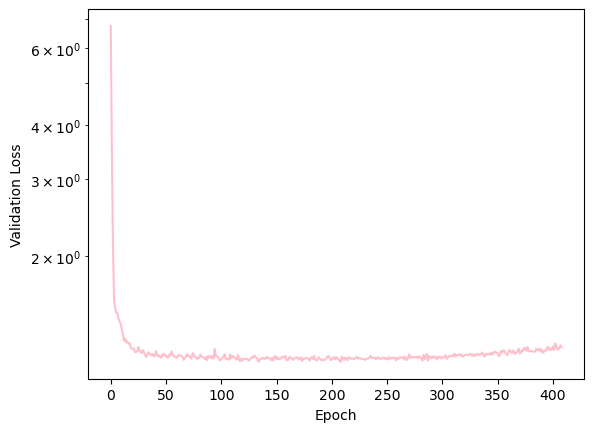

In [4]:
# Load the loss (per-epoch val_loss, written by Training.py's LossTracker)
loss = np.load('loss.npy')

plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.yscale('log')
plt.plot(loss, color='pink')
plt.show()

# Spectrum Reconstruction

#### Set up For Recon

In [ ]:
@torch.no_grad()
def reconstruct(model, flux_batch, valid_batch, ps=cfg['patch_size'], ol=cfg['overlap'], masked=False, block_k=1):
    """
    Reconstruct spectra through SpecML, overlap-averaging patches back to pixel space.

    flux_batch : (B, L) array/tensor  — raw flux (post w^2 correction, pre-normalisation)
    valid_batch: (B, L) bool array/tensor — per-pixel DQ validity mask
    ps         : patch size — must match the loaded model (default 10 for current checkpoint)
    ol         : overlap   — must match the loaded model (default 4  for current checkpoint)
    masked=False: single forward pass, all tokens visible
    masked=True : leave-one-block-out (MAE-consistent); costs N forward passes per batch
    """
    S = ps - ol


    if isinstance(flux_batch, torch.Tensor):
        flux_np  = flux_batch.cpu().numpy()
        valid_np = valid_batch.cpu().numpy().astype(bool)
    else:
        flux_np  = np.asarray(flux_batch, dtype=np.float64)
        valid_np = np.asarray(valid_batch, dtype=bool)

    B, L = flux_np.shape

    # Per-spectrum normalisation (matches Tokeniser.py's arcsinh convention):
    # arcsinh(f/scale) compresses emission-line spikes, then z-score the result.
    scale    = np.nanmedian(np.abs(flux_np), axis=1, keepdims=True).clip(1e-30)
    f_arc    = np.arcsinh(flux_np / scale)
    arc_mean = np.nanmean(f_arc, axis=1, keepdims=True)
    arc_std  = np.nanstd(f_arc,  axis=1, keepdims=True).clip(1e-10)
    f_norm   = (f_arc - arc_mean) / arc_std

    # Patchify: (B, T, ps)
    x_t   = sliding_window_view(f_norm, ps, axis=1)[:, ::S]
    X_arr = np.concatenate([
        np.nanmean(x_t, axis=2, keepdims=True),
        np.nanstd( x_t, axis=2, keepdims=True),
        x_t,
    ], axis=2).astype(np.float32)                     # (B, T, ps+2)

    # Validity: patch valid iff every pixel in it is DQ-valid
    dq_p  = sliding_window_view(valid_np, ps, axis=1)[:, ::S]  # (B, T, ps)
    V_arr = dq_p.all(axis=2)                                    # (B, T)
    X_arr[~V_arr] = 0.0

    N      = X_arr.shape[1]
    L_used = (N - 1) * S + ps

    # Recompute wavelength positional encoding for this (ps, ol) pair
    w_used    = w[:L_used]
    w_patches = sliding_window_view(w_used, ps)[::S].mean(axis=1)   # (N,)
    omegas    = 10000 ** (-2 * np.arange(cfg['D_emb'] // 2) / cfg['D_emb'])
    product   = np.outer(w_patches * 1e4, omegas)
    P_enc     = np.empty((N, cfg['D_emb']), dtype=np.float32)
    P_enc[:, 0::2] = np.sin(product)
    P_enc[:, 1::2] = np.cos(product)

    X_t = torch.from_numpy(X_arr).to(device)
    V_t = torch.from_numpy(V_arr).to(device)
    P_t = torch.from_numpy(P_enc).to(device)

    if not masked:
        out       = model.forward(X_t, V_t, P_t)   # (B, N, ps+2)
        recon_pat = out[:, :, 2:]                   # (B, N, ps) — skip mean/std slots
    else:
        # For each token t, zero out a block_k-wide block around t (matches training
        # convention: zero X values, leave V unchanged so attention still fires).
        recon_pat = torch.zeros(B, N, ps, device=device)
        half_lo, half_hi = (block_k - 1) // 2, block_k // 2
        for t in range(N):
            tlo, thi = max(0, t - half_lo), min(N - 1, t + half_hi)
            mp = X_t.clone()
            mp[:, tlo:thi+1, :] = 0.0              # zero patch values; V unchanged
            out_t = model.forward(mp, V_t, P_t)
            recon_pat[:, t, :] = out_t[:, t, 2:]

    # Overlap-average patches → pixel spectrum
    recon_pix = torch.zeros(B, L_used, device=device)
    count     = torch.zeros(B, L_used, device=device)
    for t in range(N):
        s = t * S
        recon_pix[:, s:s+ps] += recon_pat[:, t, :]
        count[:, s:s+ps]     += 1.0
    recon_pix /= count.clamp(min=1)                # (B, L_used), normalised space

    scale_t    = torch.from_numpy(scale[:, 0].astype(np.float32))
    arc_mean_t = torch.from_numpy(arc_mean[:, 0].astype(np.float32))
    arc_std_t  = torch.from_numpy(arc_std[:, 0].astype(np.float32))

    # Invert f_norm -> f_arcsinh -> flux: f = scale * sinh(f_norm * arc_std + arc_mean)
    recon_arc  = recon_pix.cpu() * arc_std_t[:, None] + arc_mean_t[:, None]
    recon_flux = scale_t[:, None] * torch.sinh(recon_arc)

    return dict(
        flux        = torch.from_numpy(flux_np[:, :L_used].astype(np.float32)),
        wave        = torch.from_numpy(w_used.astype(np.float32)),
        vmask       = torch.from_numpy(valid_np[:, :L_used]),
        flux_norm   = torch.from_numpy(f_norm[:, :L_used].astype(np.float32)),
        recon_norm  = recon_pix.cpu(),
        recon_flux  = recon_flux,
        patches     = X_t.cpu(),          # (B, N, ps+2) input patches
        recon_pat   = recon_pat.cpu(),     # (B, N, ps)   predicted flux patches
        token_vmask = V_t.cpu(),           # (B, N)
        count       = count.cpu(),         # (B, L_used) overlap count per pixel
        scale=scale_t, arc_mean=arc_mean_t, arc_std=arc_std_t,
        N=N, P=ps, S=S, L_used=L_used,
    )

#### Plotting

In [6]:
idx_show = np.where(mask_g3)[0][:4]
r = reconstruct(model, f[idx_show], dq[idx_show])
wave = r['wave'].numpy()

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
for i, ax in enumerate(axes):
    vmask = r['vmask'][i].numpy()
    ax.plot(wave, r['flux_norm'][i].numpy(),  color='steelblue', lw=0.8, label='input')
    ax.plot(wave, r['recon_norm'][i].numpy(), color='tomato',    lw=0.8, label='reconstruction')
    ax.fill_between(wave, -5, 5, where=~vmask, color='grey', alpha=0.2, label='invalid')
    ax.set_ylim(-5, 5)
    ax.set_ylabel('norm. flux')
    if i == 0:                       # ← now inside the loop
        ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('wavelength (μm)')
fig.suptitle('Spectrum Reconstruction (normalised flux) for Four Valid Spectrum in Redshift Grade')
plt.tight_layout()
plt.savefig('spectrum_reconstruction.png', dpi=150, bbox_inches='tight')
plt.show()

UnboundLocalError: cannot access local variable 'flux_np' where it is not associated with a value